# 🏆 Previsão de Placares — Copa do Mundo FIFA 2026
### Rede Neural com TensorFlow/Keras

## 📐 Arquitetura do Pipeline

```
Dados Históricos (Copa 1950–2022 + Eliminatórias 2026)
         ↓
  Engenharia de Features
  ┌─────────────────────────────────────────────────┐
  │ Elo Rating          │ Forma últimos 10 jogos    │
  │ Ranking FIFA        │ Saldo de gols (10 jogos)  │
  │ Força ofensiva      │ Força defensiva           │
  │ Head-to-Head        │ Odds (prob. implícitas)   │
  │ Temperatura clima   │ Flag sede Copa 2026       │
  └─────────────────────────────────────────────────┘
         ↓
  Validação Temporal (sem data leakage)
  ┌──────────────────────────────────────┐
  │ Treino  : Copa 1950 – 2018           │
  │ Val     : Copa 2022                  │
  │ Teste   : Eliminatórias 2026         │
  │ Previsão: 1ª Rodada Copa 2026        │
  └──────────────────────────────────────┘
         ↓
  Rede Neural Multi-Output + Loss de Poisson
  [gols_t1, gols_t2] → Placar inteiro arredondado
         ↓
  bolao_copa_previsoes.json

## 📦 Célula 1 — Instalação

In [65]:
import subprocess, sys
for p in ['tensorflow','pandas','numpy','scikit-learn',
          'requests','beautifulsoup4','matplotlib','seaborn']:
    try: __import__(p.replace('-','_'))
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',p,'-q'])
print('✅ Dependências prontas')

✅ Dependências prontas


## 📚 Célula 2 — Imports

In [66]:
import json, re, time, warnings, random, io
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

SEED = 1895
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

## 🌐 Célula 3 — Scraping: Copas 1950–2022 + Eliminatórias 2026
Fontes: Fjelstul World Cup Database (datahub.io) + Wikipedia API

In [67]:
# ── Normalização de nomes O(1) ────────────────────────────────────────────────
NOME_COD = {
    'Argentina':'ARG','Brazil':'BRA','Uruguay':'URU','Colombia':'COL',
    'Ecuador':'ECU','Paraguay':'PAR','Bolivia':'BOL','Venezuela':'VEN',
    'Peru':'PER','Chile':'CHI','United States':'USA','USA':'USA',
    'Mexico':'MEX','Canada':'CAN','Panama':'PAN','Haiti':'HAI',
    'Curaçao':'CUW','Curacao':'CUW','New Zealand':'NZL',
    'England':'ENG','Scotland':'SCO','France':'FRA','Germany':'GER',
    'West Germany':'GER','Spain':'ESP','Netherlands':'NED','Belgium':'BEL',
    'Portugal':'POR','Italy':'ITA','Croatia':'CRO','Switzerland':'SUI',
    'Sweden':'SWE','Norway':'NOR','Austria':'AUT','Denmark':'DEN',
    'Poland':'POL','Czech Republic':'CZE','Czechia':'CZE','Hungary':'HUN',
    'Romania':'ROU','Turkey':'TUR','Türkiye':'TUR','Greece':'GRE',
    'Serbia':'SRB','Ukraine':'UKR','Slovakia':'SVK','Wales':'WAL',
    'Bosnia and Herzegovina':'BIH','Bosnia-Herzegovina':'BIH','Bosnia':'BIH',
    'Russia':'RUS','Soviet Union':'URS','Yugoslavia':'YUG',
    'Czechoslovakia':'TCH','North Macedonia':'MKD','Iceland':'ISL',
    'Kosovo':'XKX','Georgia':'GEO','Kazakhstan':'KAZ','Moldova':'MDA',
    'Morocco':'MAR','Senegal':'SEN','Ghana':'GHA','Nigeria':'NGA',
    'Cameroon':'CMR',"Côte d'Ivoire":'CIV',"Cote d'Ivoire":'CIV',
    'Ivory Coast':'CIV','Algeria':'ALG','Tunisia':'TUN','Egypt':'EGY',
    'South Africa':'RSA','Cape Verde':'CPV','Cabo Verde':'CPV',
    'DR Congo':'COD','Democratic Republic of the Congo':'COD',
    'Japan':'JPN','South Korea':'KOR','Korea Republic':'KOR',
    'Iran':'IRN','Saudi Arabia':'KSA','Australia':'AUS','Qatar':'QAT',
    'Uzbekistan':'UZB','Jordan':'JOR','Iraq':'IRQ','North Korea':'PRK',
    'Zaire':'ZAI','Israel':'ISR','Cuba':'CUB','Jamaica':'JAM',
    'Honduras':'HON','Costa Rica':'CRC','Trinidad and Tobago':'TTO',
}
for c in list(set(NOME_COD.values())): NOME_COD[c] = c
NOME_COD_LOW = {k.lower(): v for k, v in NOME_COD.items()}  # lookup O(1)

def norm(nome):
    if not isinstance(nome, str): return 'UNK'
    n = nome.strip()
    if n in NOME_COD: return NOME_COD[n]
    if n.lower() in NOME_COD_LOW: return NOME_COD_LOW[n.lower()]
    return n[:3].upper()

print('✅ Normalização de nomes O(1) pronta')

✅ Normalização de nomes O(1) pronta


In [68]:
# ── Dataset completo Copa 1950–2022 (com ANO para split temporal) ─────────────
COPA_HISTORICO = [
    # (home, away, g1, g2, ano)
    # 1950
    ('Brazil','Mexico',4,0,1950),('Yugoslavia','Switzerland',3,0,1950),
    ('Brazil','Switzerland',2,2,1950),('Yugoslavia','Mexico',4,1,1950),
    ('Brazil','Yugoslavia',2,0,1950),('Switzerland','Mexico',2,1,1950),
    ('Uruguay','Bolivia',8,0,1950),('Spain','USA',3,1,1950),
    ('England','Chile',2,0,1950),('USA','England',1,0,1950),
    ('Uruguay','Spain',2,2,1950),('Uruguay','Sweden',3,2,1950),
    ('Brazil','Uruguay',1,2,1950),
    # 1954
    ('West Germany','Turkey',4,1,1954),('Hungary','South Korea',9,0,1954),
    ('Hungary','West Germany',8,3,1954),('Turkey','West Germany',2,7,1954),
    ('Uruguay','Czechoslovakia',2,0,1954),('Austria','Scotland',5,0,1954),
    ('West Germany','Austria',6,1,1954),('Hungary','Uruguay',4,2,1954),
    ('West Germany','Hungary',3,2,1954),
    # 1958
    ('West Germany','Argentina',3,1,1958),('France','Paraguay',7,3,1958),
    ('Brazil','Austria',3,0,1958),('Brazil','Sweden',5,2,1958),
    ('West Germany','Sweden',3,1,1958),('Brazil','France',5,2,1958),
    # 1962
    ('Brazil','Mexico',2,0,1962),('Brazil','Czechoslovakia',3,1,1962),
    ('Chile','Yugoslavia',2,1,1962),
    # 1966
    ('England','Uruguay',0,0,1966),('West Germany','Switzerland',5,0,1966),
    ('Portugal','Hungary',3,1,1966),('England','Mexico',2,0,1966),
    ('Portugal','Brazil',3,1,1966),('England','Argentina',1,0,1966),
    ('West Germany','Uruguay',4,0,1966),('England','West Germany',4,2,1966),
    # 1970
    ('Brazil','Czechoslovakia',4,1,1970),('West Germany','Morocco',2,1,1970),
    ('Brazil','England',1,0,1970),('West Germany','Peru',3,1,1970),
    ('Italy','Mexico',4,1,1970),('Brazil','Uruguay',3,1,1970),
    ('Italy','West Germany',4,3,1970),('Brazil','Italy',4,1,1970),
    # 1974
    ('West Germany','Chile',1,0,1974),('Brazil','Yugoslavia',0,0,1974),
    ('Scotland','Zaire',2,0,1974),('Yugoslavia','Brazil',1,0,1974),
    ('West Germany','Poland',1,0,1974),('Netherlands','Brazil',2,0,1974),
    ('West Germany','Netherlands',2,1,1974),
    # 1978
    ('Argentina','Hungary',2,1,1978),('Italy','France',2,1,1978),
    ('Brazil','Sweden',1,1,1978),('Argentina','Netherlands',3,1,1978),
    # 1982
    ('Italy','Poland',2,0,1982),('Brazil','Argentina',3,1,1982),
    ('Italy','Brazil',3,2,1982),('West Germany','France',3,3,1982),
    ('Italy','West Germany',3,1,1982),
    # 1986
    ('Argentina','South Korea',3,1,1986),('France','Canada',1,0,1986),
    ('Brazil','Spain',1,0,1986),('Argentina','Uruguay',1,0,1986),
    ('Argentina','England',2,1,1986),('West Germany','France',2,0,1986),
    ('Argentina','West Germany',3,2,1986),
    # 1990
    ('West Germany','Yugoslavia',4,1,1990),('Brazil','Sweden',2,1,1990),
    ('Argentina','USSR',2,0,1990),('Italy','Austria',1,0,1990),
    ('West Germany','Netherlands',2,1,1990),('Argentina','Brazil',1,0,1990),
    ('West Germany','England',1,1,1990),('West Germany','Argentina',1,0,1990),
    # 1994
    ('Germany','Bolivia',1,0,1994),('Brazil','Russia',2,0,1994),
    ('Argentina','Greece',4,0,1994),('Italy','Ireland',1,0,1994),
    ('Germany','South Korea',3,2,1994),('Brazil','USA',1,0,1994),
    ('Italy','Spain',2,1,1994),('Germany','Bulgaria',1,2,1994),
    # 1998
    ('Brazil','Scotland',2,1,1998),('France','South Africa',3,0,1998),
    ('Argentina','Japan',1,0,1998),('Germany','USA',2,0,1998),
    ('Brazil','Morocco',3,0,1998),('France','Denmark',2,1,1998),
    ('Brazil','Chile',4,1,1998),('Germany','Croatia',0,3,1998),
    ('Brazil','Netherlands',1,1,1998),('France','Croatia',2,1,1998),
    ('Brazil','France',0,3,1998),
    # 2002
    ('France','Senegal',0,1,2002),('Germany','Saudi Arabia',8,0,2002),
    ('Brazil','Turkey',2,1,2002),('Japan','Russia',1,0,2002),
    ('Brazil','Belgium',2,0,2002),('England','Brazil',1,2,2002),
    ('Germany','USA',1,0,2002),('Brazil','England',2,1,2002),
    ('Germany','South Korea',1,0,2002),('Brazil','Germany',2,0,2002),
    # 2006
    ('Germany','Costa Rica',4,2,2006),('England','Paraguay',1,0,2006),
    ('Argentina','Ivory Coast',2,1,2006),('Brazil','Croatia',1,0,2006),
    ('Germany','Poland',1,0,2006),('Brazil','Australia',2,0,2006),
    ('England','Ecuador',1,0,2006),('Germany','Sweden',2,0,2006),
    ('France','Brazil',1,0,2006),('Italy','Ukraine',3,0,2006),
    ('Germany','Italy',0,2,2006),('Italy','France',1,1,2006),
    # 2010
    ('South Africa','Mexico',1,1,2010),('France','Uruguay',0,0,2010),
    ('Argentina','Nigeria',1,0,2010),('England','USA',1,1,2010),
    ('Germany','Australia',4,0,2010),('Brazil','North Korea',2,1,2010),
    ('Argentina','South Korea',4,1,2010),('Germany','Ghana',1,0,2010),
    ('Brazil','Chile',3,0,2010),('Argentina','Mexico',3,1,2010),
    ('Germany','England',4,1,2010),('Uruguay','South Korea',2,1,2010),
    ('Argentina','Germany',0,4,2010),('Spain','Germany',1,0,2010),
    ('Netherlands','Uruguay',3,2,2010),('Spain','Netherlands',1,0,2010),
    # 2014
    ('Brazil','Croatia',3,1,2014),('Argentina','Bosnia',2,1,2014),
    ('Germany','Portugal',4,0,2014),('Spain','Netherlands',1,5,2014),
    ('France','Honduras',3,0,2014),('Brazil','Mexico',0,0,2014),
    ('Germany','Ghana',2,2,2014),('Brazil','Chile',1,1,2014),
    ('Germany','Algeria',2,1,2014),('Argentina','Switzerland',1,0,2014),
    ('France','Germany',0,1,2014),('Brazil','Germany',1,7,2014),
    ('Germany','Argentina',1,0,2014),
    # 2018
    ('Russia','Saudi Arabia',5,0,2018),('Germany','Mexico',0,1,2018),
    ('Brazil','Switzerland',1,1,2018),('France','Australia',2,1,2018),
    ('Argentina','Iceland',1,1,2018),('Portugal','Spain',3,3,2018),
    ('England','Tunisia',2,1,2018),('Colombia','Japan',1,2,2018),
    ('Belgium','Panama',3,0,2018),('South Korea','Germany',2,0,2018),
    ('Brazil','Mexico',2,0,2018),('Japan','Belgium',2,3,2018),
    ('Uruguay','Portugal',2,1,2018),('France','Argentina',4,3,2018),
    ('Belgium','Brazil',2,1,2018),('France','Uruguay',2,0,2018),
    ('Belgium','France',0,1,2018),('England','Croatia',1,2,2018),
    ('France','Croatia',4,2,2018),
    # 2022
    ('Qatar','Ecuador',0,2,2022),('England','Iran',6,2,2022),
    ('Senegal','Netherlands',0,2,2022),('Argentina','Saudi Arabia',1,2,2022),
    ('France','Australia',4,1,2022),('Germany','Japan',1,2,2022),
    ('Spain','Costa Rica',7,0,2022),('Belgium','Canada',1,0,2022),
    ('Brazil','Serbia',2,0,2022),('Morocco','Croatia',0,0,2022),
    ('Argentina','Mexico',2,0,2022),('France','Denmark',2,1,2022),
    ('Japan','Spain',2,1,2022),('Morocco','Belgium',2,0,2022),
    ('Brazil','Switzerland',1,0,2022),('Portugal','Ghana',3,2,2022),
    ('Netherlands','USA',3,1,2022),('England','Senegal',3,0,2022),
    ('France','Poland',3,1,2022),('Argentina','Australia',2,1,2022),
    ('Brazil','South Korea',4,1,2022),('Morocco','Spain',0,0,2022),
    ('England','France',1,2,2022),('Argentina','Netherlands',2,2,2022),
    ('Croatia','Brazil',1,1,2022),('France','Morocco',2,0,2022),
    ('Argentina','Croatia',3,0,2022),('Argentina','France',3,3,2022),
]

df_copa = pd.DataFrame(COPA_HISTORICO,
    columns=['home_team','away_team','gols_home','gols_away','year'])
df_copa['t1'] = df_copa['home_team'].apply(norm)
df_copa['t2'] = df_copa['away_team'].apply(norm)

print(f'✅ Copa 1950–2022: {len(df_copa)} jogos')
print(f'   Anos: {sorted(df_copa.year.unique())}')

✅ Copa 1950–2022: 195 jogos
   Anos: [np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]


In [69]:
# ── Eliminatórias 2026 via Wikipedia API ──────────────────────────────────────
WIKI_API = 'https://en.wikipedia.org/w/api.php'

def wikipedia_h2h(titulo, apelido=''):
    print(f'  📥 {apelido}')
    params = {'action':'parse','page':titulo,'prop':'text','format':'json'}
    resultados = []
    try:
        r = requests.get(WIKI_API, params=params, headers=HEADERS, timeout=25)
        html = r.json()['parse']['text']['*']
        soup = BeautifulSoup(html, 'html.parser')
        for table in soup.find_all('table',{'class': lambda c: c and 'wikitable' in c}):
            rows = table.find_all('tr')
            if len(rows) < 3: continue
            headers = [c.get_text(strip=True) for c in rows[0].find_all(['th','td'])]
            for row in rows[1:]:
                cells = row.find_all(['th','td'])
                if not cells: continue
                home = cells[0].get_text(strip=True)
                for j, cell in enumerate(cells[1:], 1):
                    m = re.match(r'^(\d+)[–\-](\d+)$', cell.get_text(strip=True))
                    if m and j < len(headers) and headers[j] != home:
                        resultados.append({'home_team':home,'away_team':headers[j],
                                           'gols_home':int(m.group(1)),'gols_away':int(m.group(2))})
    except Exception as e:
        print(f'    ⚠️  {e}')
    print(f'     → {len(resultados)} jogos')
    return pd.DataFrame(resultados) if resultados else pd.DataFrame()

PAGINAS = [
    ('2026 FIFA World Cup qualification (CONMEBOL)','CONMEBOL'),
    ('2026 FIFA World Cup qualification (UEFA)','UEFA'),
    ('2026 FIFA World Cup qualification (CAF)','CAF'),
    ('2026 FIFA World Cup qualification (AFC)','AFC'),
    ('2026 FIFA World Cup qualification (CONCACAF)','CONCACAF'),
    ('2026 FIFA World Cup qualification (OFC)','OFC'),
]

frames = []
for titulo, ape in PAGINAS:
    df_tmp = wikipedia_h2h(titulo, ape)
    if not df_tmp.empty:
        df_tmp['fonte'] = ape; frames.append(df_tmp)
    time.sleep(0.4)

# Fallback
ELIM_FB = [
    ('Argentina','Ecuador',1,0),('Argentina','Bolivia',3,0),('Argentina','Uruguay',0,2),
    ('Argentina','Colombia',1,0),('Argentina','Chile',1,0),('Argentina','Brazil',1,0),
    ('Brazil','Bolivia',5,1),('Brazil','Peru',4,0),('Brazil','Colombia',2,1),
    ('Brazil','Chile',3,0),('Colombia','Bolivia',3,0),('Colombia','Venezuela',3,6),
    ('Uruguay','Bolivia',3,0),('Uruguay','Peru',3,0),('Uruguay','Paraguay',2,0),
    ('Ecuador','Colombia',1,2),('Ecuador','Bolivia',4,0),
    ('England','Albania',5,0),('England','San Marino',10,0),('England','Greece',3,0),
    ('Scotland','Croatia',2,1),('France','Israel',4,1),('France','Belgium',2,0),
    ('Germany','Hungary',5,0),('Germany','Bosnia-Herzegovina',7,0),
    ('Spain','Denmark',5,0),('Spain','Netherlands',3,2),
    ('Netherlands','Hungary',4,0),('Netherlands','Malta',7,0),
    ('Portugal','Poland',5,1),('Portugal','Croatia',2,0),
    ('Belgium','Romania',3,0),('Belgium','Austria',2,0),
    ('Sweden','Estonia',3,0),('Norway','Moldova',11,1),
    ('Morocco','Tanzania',5,0),('Morocco','South Africa',2,0),
    ('Senegal','Mauritania',3,0),('Ivory Coast','Zambia',2,1),
    ('Algeria','Mozambique',2,0),('Egypt','Djibouti',4,0),
    ('Ghana','Angola',1,0),('Tunisia','Equatorial Guinea',3,0),
    ('DR Congo','Tanzania',3,0),
    ('Japan','China',7,0),('Japan','Syria',5,0),
    ('South Korea','Thailand',5,0),('Saudi Arabia','Bangladesh',3,0),
    ('Iran','Uzbekistan',1,0),('Australia','Bangladesh',7,0),
    ('USA','Panama',4,0),('USA','Mexico',2,0),('Canada','Jamaica',4,0),
    ('Mexico','Jamaica',2,0),('New Zealand','Fiji',8,0),
]
df_elim_fb = pd.DataFrame(ELIM_FB, columns=['home_team','away_team','gols_home','gols_away'])
df_elim_fb['fonte'] = 'fallback'

df_elim = pd.concat(frames, ignore_index=True).drop_duplicates(
    subset=['home_team','away_team','gols_home','gols_away']) if frames else pd.DataFrame()

if len(df_elim) < 50:
    df_elim = df_elim_fb
    print(f'⚠️  Usando fallback: {len(df_elim)} jogos')
else:
    df_elim = pd.concat([df_elim, df_elim_fb]).drop_duplicates(
        subset=['home_team','away_team','gols_home','gols_away']).reset_index(drop=True)
    print(f'✅ Eliminatórias: {len(df_elim)} jogos')

df_elim['t1'] = df_elim['home_team'].apply(norm)
df_elim['t2'] = df_elim['away_team'].apply(norm)
df_elim['year'] = 2025  # eliminatórias = mais recentes

  📥 CONMEBOL
     → 90 jogos
  📥 UEFA
     → 200 jogos
  📥 CAF
     → 253 jogos
  📥 AFC
     → 233 jogos
  📥 CONCACAF
     → 97 jogos
  📥 OFC
     → 12 jogos
✅ Eliminatórias: 276 jogos


## ⚡ Célula 4 — Elo Rating

O **Elo Rating** é um sistema de ranking dinâmico que atualiza a força de cada time após cada partida:

```
E₁ = 1 / (1 + 10^((R₂ - R₁) / 400))   # probabilidade esperada
S₁ = 1 (vitória) | 0.5 (empate) | 0 (derrota)
R₁_novo = R₁ + K × (S₁ - E₁)
```

**K = 40** para Copa do Mundo (jogos de alta importância).  
**K = 30** para eliminatórias.  
Margem de gols amplifica o fator K (goleadas valem mais).

> 📖 Base: sistema usado pelo próprio **FIFA World Rankings** e pelo **World Football Elo Ratings**.

In [70]:
# ── Cálculo do Elo Rating cronológico ─────────────────────────────────────────

ELO_INICIAL = 1500

def fator_margem(g1, g2):
    """
    Amplifica K conforme margem de gols (inspirado no sistema Elo da FIFA).
    Vitória por 1: ×1.0 | por 2: ×1.5 | por 3+: ×1.75 | por 4+: ×2.0
    """
    diff = abs(g1 - g2)
    if diff == 0: return 1.0
    if diff == 1: return 1.0
    if diff == 2: return 1.5
    if diff == 3: return 1.75
    return 2.0

def atualizar_elo(elo, t1, t2, g1, g2, K=40):
    """Atualiza os ratings Elo de dois times após uma partida."""
    r1 = elo.get(t1, ELO_INICIAL)
    r2 = elo.get(t2, ELO_INICIAL)
    e1 = 1 / (1 + 10**((r2 - r1) / 400))  # prob. esperada t1
    s1 = 1.0 if g1 > g2 else (0.5 if g1 == g2 else 0.0)
    fm = fator_margem(g1, g2)
    elo[t1] = r1 + K * fm * (s1 - e1)
    elo[t2] = r2 + K * fm * ((1 - s1) - (1 - e1))
    return elo

# Processa cronologicamente: Copa 1950→2022 depois Eliminatórias 2026
elo_ratings = {}
df_copa_sorted = df_copa.sort_values('year')

for _, row in df_copa_sorted.iterrows():
    elo_ratings = atualizar_elo(elo_ratings, row.t1, row.t2,
                                 row.gols_home, row.gols_away, K=40)

# Snapshot após Copa 2018 (para validação temporal)
df_ate2018 = df_copa_sorted[df_copa_sorted.year <= 2018]
elo_2018 = {}
for _, row in df_ate2018.iterrows():
    elo_2018 = atualizar_elo(elo_2018, row.t1, row.t2,
                              row.gols_home, row.gols_away, K=40)

# Eliminatórias (K=30, menos peso que Copa)
for _, row in df_elim.iterrows():
    elo_ratings = atualizar_elo(elo_ratings, row.t1, row.t2,
                                 row.gols_home, row.gols_away, K=30)

print('🏆 Top 15 Elo após Copa 1950–2022 + Eliminatórias 2026:')
top15 = sorted(elo_ratings.items(), key=lambda x: -x[1])[:15]
for i,(t,r) in enumerate(top15,1):
    print(f'  {i:2}. {t}: {r:.0f}')

🏆 Top 15 Elo após Copa 1950–2022 + Eliminatórias 2026:
   1. FRA: 1778
   2. 1: 1762
   3. ITA: 1722
   4. BRA: 1718
   5. GER: 1713
   6. ARG: 1681
   7. ENG: 1643
   8. NED: 1622
   9. JPN: 1607
  10. URU: 1586
  11. POR: 1586
  12. ESP: 1570
  13. IND: 1568
  14. BEL: 1563
  15. 3: 1557


## 📊 Célula 5 — Forma e Força dos Times (últimos 10 jogos)

Calculamos para cada time (a partir do histórico completo):
- **Forma**: aproveitamento % nos últimos 10 jogos
- **Saldo de gols**: gols marcados − sofridos nos últimos 10
- **Força ofensiva**: média de gols marcados nos últimos 10
- **Força defensiva**: média de gols sofridos nos últimos 10 (menor = melhor)

In [71]:
# ── Reconstrói histórico de jogos por time (cronológico) ──────────────────────
def historico_por_time(df_copa, df_elim):
    """
    Retorna dict: time → lista cronológica de (gols_marcados, gols_sofridos)
    """
    hist = {}
    # Copa (ordenada por ano)
    for _, r in df_copa.sort_values('year').iterrows():
        for time, gm, gs in [(r.t1, r.gols_home, r.gols_away),
                              (r.t2, r.gols_away, r.gols_home)]:
            hist.setdefault(time, []).append((int(gm), int(gs)))
    # Eliminatórias (mais recentes)
    for _, r in df_elim.iterrows():
        for time, gm, gs in [(r.t1, r.gols_home, r.gols_away),
                              (r.t2, r.gols_away, r.gols_home)]:
            hist.setdefault(time, []).append((int(gm), int(gs)))
    return hist

HISTORICO_TIMES = historico_por_time(df_copa, df_elim)

def calcular_forma(time, n=10):
    """
    Calcula forma, saldo, força ofensiva e defensiva nos últimos n jogos.
    Retorna (forma_pct, saldo_gols, forca_of, forca_def)
    """
    jogos = HISTORICO_TIMES.get(time, [])
    ultimos = jogos[-n:] if len(jogos) >= n else jogos
    if not ultimos:
        return (45.0, 0.0, 1.0, 1.2)  # default para times sem histórico

    pts = sum(3 if gm>gs else (1 if gm==gs else 0) for gm,gs in ultimos)
    forma = pts / (len(ultimos) * 3) * 100
    saldo = sum(gm - gs for gm, gs in ultimos) / len(ultimos)
    forca_of  = sum(gm for gm, _ in ultimos) / len(ultimos)
    forca_def = sum(gs for _, gs in ultimos) / len(ultimos)
    return (round(forma, 1), round(saldo, 2),
            round(forca_of, 2), round(forca_def, 2))

# Amostra
print('  Time │ Forma% │ Saldo │ At.Ofens │ At.Def')
print('  ─────┼────────┼───────┼──────────┼───────')
for t in ['ARG','BRA','FRA','GER','ENG','ESP','MAR','QAT','HAI','CUW']:
    f,s,of,df_ = calcular_forma(t)
    print(f'  {t:4} │ {f:5.1f}% │ {s:+5.2f} │   {of:5.2f}    │ {df_:5.2f}')

  Time │ Forma% │ Saldo │ At.Ofens │ At.Def
  ─────┼────────┼───────┼──────────┼───────
  ARG  │  76.7% │ +0.90 │    1.70    │  0.80
  BRA  │  73.3% │ +1.60 │    2.30    │  0.70
  FRA  │  93.3% │ +1.70 │    2.70    │  1.00
  GER  │  63.3% │ +1.70 │    2.60    │  0.90
  ENG  │  63.3% │ +2.10 │    3.30    │  1.20
  ESP  │  56.7% │ +0.90 │    2.30    │  1.40
  MAR  │  45.8% │ +0.38 │    1.25    │  0.88
  QAT  │   0.0% │ -2.00 │    0.00    │  2.00
  HAI  │  45.0% │ +0.00 │    1.00    │  1.20
  CUW  │  45.0% │ +0.00 │    1.00    │  1.20


## 🧮 Célula 6 — Engenharia de Features (14 dimensões)

```
 [0]  elo_t1            Elo rating do time 1
 [1]  elo_t2            Elo rating do time 2
 [2]  diff_elo          Diferença de Elo (t1 - t2)
 [3]  rank_t1           Ranking FIFA (menor = melhor)
 [4]  rank_t2
 [5]  forma_t1          Aproveitamento % últimos 10 jogos
 [6]  forma_t2
 [7]  saldo_t1          Saldo médio de gols últimos 10
 [8]  saldo_t2
 [9]  forca_of_t1       Média gols marcados últimos 10
[10]  forca_of_t2
[11]  forca_def_t1      Média gols sofridos últimos 10
[12]  forca_def_t2
[13]  h2h_vit_t1        Head-to-head: vitórias t1
[14]  h2h_emp           Head-to-head: empates
[15]  h2h_vit_t2        Head-to-head: vitórias t2
[16]  prob_vit_t1       Probabilidade implícita (odds) vitória t1
[17]  prob_emp          Probabilidade implícita empate
[18]  prob_vit_t2       Probabilidade implícita vitória t2
[19]  temp_dist_t1      |temperatura_país_t1 - 14°C|
[20]  temp_dist_t2      |temperatura_país_t2 - 14°C|
[21]  host_flag         +1=t1 é sede, -1=t2 é sede, 0=neutro
```

In [72]:
RANKING_FIFA = {
    'ARG':1,'FRA':2,'ENG':3,'BRA':4,'POR':5,'BEL':6,'NED':7,'ESP':8,
    'GER':9,'URU':10,'COL':11,'CRO':12,'MAR':13,'SEN':14,'SUI':15,
    'USA':16,'MEX':17,'JPN':19,'ECU':20,'AUT':21,'TUR':22,'KOR':23,
    'SWE':24,'CAN':25,'IRN':26,'NOR':27,'AUS':28,'EGY':29,'SCO':30,
    'GHA':31,'QAT':32,'TUN':33,'PAR':34,'CZE':35,'ALG':36,'CIV':37,
    'KSA':38,'IRQ':39,'UZB':40,'JOR':41,'RSA':42,'CPV':43,'BIH':44,
    'PAN':45,'NZL':46,'COD':47,'HAI':48,'CUW':49,
    # históricos
    'ITA':12,'YUG':20,'URS':15,'TCH':25,'ZAI':60,'GDR':30,
    'HON':65,'JAM':60,'PRK':110,'RUS':35,'CHI':35,'BOL':55,
}

TEMPERATURA = {
    'ARG':16.3,'BRA':25.4,'URU':18.0,'COL':25.0,'ECU':21.4,'PAR':23.9,
    'BOL':20.8,'VEN':25.7,'PER':20.1,'CHI':11.4,'USA':12.8,'MEX':21.3,
    'CAN':-5.4,'PAN':25.6,'HAI':24.9,'CUW':28.4,'CRC':24.8,'JAM':25.9,
    'ENG': 9.4,'SCO': 7.8,'FRA':12.1,'GER': 9.8,'ESP':13.1,'NED':10.6,
    'BEL':10.5,'POR':15.9,'ITA':13.0,'CRO':12.6,'SUI': 7.0,'SWE': 2.8,
    'NOR': 1.6,'AUT': 7.3,'DEN': 8.1,'POL': 8.7,'CZE': 9.1,'HUN':11.0,
    'ROU':10.8,'TUR':12.7,'GRE':13.2,'SRB':11.7,'UKR': 9.0,'SVK': 9.5,
    'WAL': 9.2,'BIH':10.9,'RUS':-5.1,'ISL': 4.3,'XKX':10.8,'GEO':11.5,
    'KAZ': 5.0,'MDA':11.0,
    'MAR':18.1,'SEN':28.9,'GHA':27.7,'NGA':27.3,'CMR':24.8,'CIV':26.8,
    'ALG':23.6,'TUN':20.5,'EGY':23.1,'RSA':18.2,'CPV':22.5,'COD':24.4,
    'ETH':23.4,'NAM':20.5,'BEN':28.0,
    'JPN':11.8,'KOR':12.6,'IRN':18.3,'KSA':25.9,'AUS':22.1,'QAT':28.0,
    'UZB':13.1,'JOR':20.1,'IRQ':23.0,'PRK': 8.5,'KUW':26.3,
    'NZL':12.0,'FIJ':24.7,
    'ZAI':24.4,'URS':-3.0,'YUG':11.5,'TCH': 9.5,'GDR': 9.5,
}

H2H = {
    ('MEX','RSA'):(3,2,1),('KOR','CZE'):(2,2,2),('CAN','BIH'):(1,0,0),
    ('USA','PAR'):(3,1,1),('HAI','SCO'):(0,0,1),('AUS','TUR'):(1,1,2),
    ('BRA','MAR'):(3,1,0),('QAT','SUI'):(0,0,3),('CIV','ECU'):(1,1,0),
    ('GER','CUW'):(2,0,0),('NED','JPN'):(2,1,1),('SWE','TUN'):(2,1,0),
    ('KSA','URU'):(0,1,3),('ESP','CPV'):(2,0,0),('IRN','NZL'):(1,1,0),
    ('BEL','EGY'):(2,2,1),('FRA','SEN'):(4,1,1),('IRQ','NOR'):(0,1,2),
    ('ARG','ALG'):(1,1,0),('AUT','JOR'):(1,0,0),('GHA','PAN'):(1,1,0),
    ('ENG','CRO'):(4,2,1),('POR','COD'):(1,0,0),('UZB','COL'):(0,0,2),
}

ODDS = {
    'jogo1':(2.20,3.10,3.50),'jogo2':(2.40,3.20,3.00),'jogo3':(1.90,3.40,4.00),
    'jogo4':(1.70,3.50,5.00),'jogo5':(5.50,3.80,1.60),'jogo6':(2.60,3.10,2.80),
    'jogo7':(1.40,4.50,7.00),'jogo8':(5.00,3.70,1.65),'jogo9':(2.20,3.20,3.30),
    'jogo10':(1.30,5.00,9.00),'jogo11':(1.80,3.50,4.50),'jogo12':(1.75,3.60,4.80),
    'jogo13':(4.00,3.30,1.85),'jogo14':(1.25,5.50,10.0),'jogo15':(2.30,3.20,3.10),
    'jogo16':(1.60,3.60,5.50),'jogo17':(1.35,4.80,8.50),'jogo18':(3.80,3.30,1.95),
    'jogo19':(1.30,5.00,9.50),'jogo20':(1.65,3.70,5.00),'jogo21':(2.50,3.20,2.90),
    'jogo22':(1.55,3.80,5.50),'jogo23':(1.35,4.80,8.00),'jogo24':(4.50,3.20,1.75),
}

SEDE_2026 = {'USA','CAN','MEX'}
TEMP_IDEAL = 14.0

def odds2prob(o1,oe,o2):
    p1,pe,p2 = 1/o1,1/oe,1/o2; t=p1+pe+p2
    return p1/t, pe/t, p2/t

PROBS = {j: odds2prob(*v) for j,v in ODDS.items()}

def extrair_features(t1, t2, jogo_id=None, elo_snap=None):
    """
    22 features por confronto — sem GDP/população (removidos na auditoria).
    elo_snap: dicionário de Elo a usar (permite usar snapshot temporal).
    """
    elo = elo_snap if elo_snap is not None else elo_ratings

    e1 = elo.get(t1, ELO_INICIAL); e2 = elo.get(t2, ELO_INICIAL)
    r1 = RANKING_FIFA.get(t1, 80);  r2 = RANKING_FIFA.get(t2, 80)

    f1 = calcular_forma(t1); f2 = calcular_forma(t2)

    hk = (t1,t2) if (t1,t2) in H2H else (t2,t1)
    if hk in H2H:
        h = H2H[hk]
        if hk != (t1,t2): h=(h[2],h[1],h[0])
    else:
        h = (1,1,1)

    if jogo_id and jogo_id in PROBS:
        pr = PROBS[jogo_id]
    else:
        # estima prob via Elo
        p1 = 1/(1+10**((e2-e1)/400)); p2=1-p1; pe=0.25; s=p1+pe+p2
        pr = (p1/s, pe/s, p2/s)

    td1 = abs(TEMPERATURA.get(t1, 14) - TEMP_IDEAL)
    td2 = abs(TEMPERATURA.get(t2, 14) - TEMP_IDEAL)

    is_copa = jogo_id is not None and str(jogo_id).startswith('jogo')
    if is_copa:
        host = 1.0 if t1 in SEDE_2026 else (-1.0 if t2 in SEDE_2026 else 0.0)
    else:
        host = 0.0  # campo neutro no treino

    return [
        e1, e2, e1-e2,                   # [0-2]  Elo
        r1, r2,                           # [3-4]  Ranking FIFA
        f1[0], f2[0],                     # [5-6]  Forma %
        f1[1], f2[1],                     # [7-8]  Saldo médio
        f1[2], f2[2],                     # [9-10] Força ofensiva
        f1[3], f2[3],                     # [11-12] Força defensiva
        h[0], h[1], h[2],                 # [13-15] H2H
        pr[0], pr[1], pr[2],              # [16-18] Odds
        td1, td2,                         # [19-20] Temperatura
        host,                             # [21]   Sede
    ]

N_FEATURES = len(extrair_features('ARG','BRA'))
print(f'✅ {N_FEATURES} features por jogo')
nomes_f = ['elo_t1','elo_t2','diff_elo','rank_t1','rank_t2',
           'forma_t1','forma_t2','saldo_t1','saldo_t2',
           'forca_of_t1','forca_of_t2','forca_def_t1','forca_def_t2',
           'h2h_v1','h2h_emp','h2h_v2',
           'prob_v1','prob_emp','prob_v2',
           'temp_dist_t1','temp_dist_t2','host_flag']
print('\n  Feature         │ Valor (ARG vs BRA)')
print('  ────────────────┼───────────────────')
ex = extrair_features('ARG','BRA','jogo19')
for n,v in zip(nomes_f,ex):
    print(f'  {n:15} │ {v:.4f}')

✅ 22 features por jogo

  Feature         │ Valor (ARG vs BRA)
  ────────────────┼───────────────────
  elo_t1          │ 1681.4183
  elo_t2          │ 1718.3145
  diff_elo        │ -36.8962
  rank_t1         │ 1.0000
  rank_t2         │ 4.0000
  forma_t1        │ 76.7000
  forma_t2        │ 73.3000
  saldo_t1        │ 0.9000
  saldo_t2        │ 1.6000
  forca_of_t1     │ 1.7000
  forca_of_t2     │ 2.3000
  forca_def_t1    │ 0.8000
  forca_def_t2    │ 0.7000
  h2h_v1          │ 1.0000
  h2h_emp         │ 1.0000
  h2h_v2          │ 1.0000
  prob_v1         │ 0.7159
  prob_emp        │ 0.1861
  prob_v2         │ 0.0980
  temp_dist_t1    │ 2.3000
  temp_dist_t2    │ 11.4000
  host_flag       │ 0.0000


## 📅 Célula 7 — Split Temporal (sem data leakage)

```
TREINO   │ Copa 1950–2018  (dados do passado)
─────────┼──────────────────────────────────────────────
VAL      │ Copa 2022       (avalia generalização futura)
─────────┼──────────────────────────────────────────────
TESTE    │ Eliminatórias 2026 (dados mais recentes)
─────────┼──────────────────────────────────────────────
PREVISÃO │ 24 jogos 1ª rodada Copa 2026
```

> ⚠️ **Por que isso importa?** Com `train_test_split` aleatório, o modelo pode treinar
> com dados de 2022 e ser validado em 2014 — aprendendo do futuro. O split temporal
> garante que a validação seja genuinamente "out-of-sample".

In [73]:
# ── Constrói os 4 conjuntos com split temporal ────────────────────────────────

def build_dataset(df_jogos, elo_snap, label='', espelhar=True):
    """
    Constrói X, y1, y2 a partir de um DataFrame de jogos.
    espelhar=True: duplica cada jogo (t1↔t2) para eliminar viés posicional.
    """
    X, y1, y2 = [], [], []
    for _, r in df_jogos.iterrows():
        t1,t2 = r.t1, r.t2
        g1,g2 = int(r.gols_home), int(r.gols_away)
        feats = extrair_features(t1, t2, elo_snap=elo_snap)
        X.append(feats); y1.append(g1); y2.append(g2)
        if espelhar:
            feats_inv = extrair_features(t2, t1, elo_snap=elo_snap)
            X.append(feats_inv); y1.append(g2); y2.append(g1)
    X  = np.array(X,  dtype=np.float32)
    y1 = np.array(y1, dtype=np.float32)
    y2 = np.array(y2, dtype=np.float32)
    v1 = (y1>y2).sum(); em=(y1==y2).sum(); v2=(y2>y1).sum(); tot=len(y1)
    print(f'  {label:12}: {X.shape[0]:4} amostras │ '
          f'V1:{v1/tot*100:.0f}% E:{em/tot*100:.0f}% V2:{v2/tot*100:.0f}%')
    return X, y1, y2

# Elo snapshot até 2018 para treino (evita usar info do futuro)
df_treino_raw = df_copa[df_copa.year <= 2018].copy()
df_val_raw    = df_copa[df_copa.year == 2022].copy()

print('📅 SPLIT TEMPORAL')
print('─'*60)
X_tr, y_tr1, y_tr2 = build_dataset(df_treino_raw, elo_2018,
                                     label='Treino≤2018', espelhar=True)
X_val, y_val1, y_val2 = build_dataset(df_val_raw, elo_ratings,
                                        label='Val 2022', espelhar=True)

# Dataset de eliminatórias para teste adicional
df_elim_clean = df_elim[~(df_elim.t1=='UNK') & ~(df_elim.t2=='UNK')].copy()
X_test, y_test1, y_test2 = build_dataset(df_elim_clean, elo_ratings,
                                           label='Elim 2026', espelhar=True)

print('─'*60)
print(f'  Total treino : {len(y_tr1)} amostras (balanceadas)')

# Pré-processamento — scaler ajustado APENAS no treino
scaler = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_val_sc  = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# Jogos da Copa 2026
JOGOS_2026 = [
    ('jogo1','MEX','RSA'), ('jogo2','KOR','CZE'), ('jogo3','CAN','BIH'),
    ('jogo4','USA','PAR'), ('jogo5','HAI','SCO'), ('jogo6','AUS','TUR'),
    ('jogo7','BRA','MAR'), ('jogo8','QAT','SUI'), ('jogo9','CIV','ECU'),
    ('jogo10','GER','CUW'),('jogo11','NED','JPN'),('jogo12','SWE','TUN'),
    ('jogo13','KSA','URU'),('jogo14','ESP','CPV'),('jogo15','IRN','NZL'),
    ('jogo16','BEL','EGY'),('jogo17','FRA','SEN'),('jogo18','IRQ','NOR'),
    ('jogo19','ARG','ALG'),('jogo20','AUT','JOR'),('jogo21','GHA','PAN'),
    ('jogo22','ENG','CRO'),('jogo23','POR','COD'),('jogo24','UZB','COL'),
]
X_copa = np.array([extrair_features(t1,t2,jid) for jid,t1,t2 in JOGOS_2026],
                   dtype=np.float32)
X_copa_sc = scaler.transform(X_copa)
print(f'\n  Copa 2026 (previsão): {X_copa_sc.shape}')

📅 SPLIT TEMPORAL
────────────────────────────────────────────────────────────
  Treino≤2018 :  334 amostras │ V1:45% E:11% V2:45%
  Val 2022    :   56 amostras │ V1:41% E:18% V2:41%
  Elim 2026   :  552 amostras │ V1:44% E:13% V2:44%
────────────────────────────────────────────────────────────
  Total treino : 334 amostras (balanceadas)

  Copa 2026 (previsão): (24, 22)


## 🧠 Célula 8 — Rede Neural Multi-Output com Poisson Loss

### Por que Poisson Loss?
Gols são **dados de contagem** (0, 1, 2, 3...) e seguem aproximadamente uma **distribuição de Poisson**.  
A Poisson Loss maximiza a verossimilhança dessa distribuição:

```
L = ŷ - y × log(ŷ)
```

Isso é fundamentalmente mais correto do que MSE ou Huber para gols,  
pois trata a diferença entre 0→1 gol diferente de 3→4 gols (escala log).

> 📖 Referência: Dixon & Coles (1997) — *Modelling Association Football Scores*

In [74]:
def criar_modelo(input_shape):
    """
    Rede Multi-Output:
      Input → Tronco compartilhado → [gols_t1, gols_t2]
    Poisson Loss: correta para dados de contagem (gols).
    """
    inp = keras.Input(shape=(input_shape,), name='features')

    # ── Tronco compartilhado ──────────────────────────────────────────────────
    x = layers.Dense(128, name='d1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, name='d2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(32, activation='relu', name='d3')(x)
    x = layers.Dropout(0.10)(x)
    x = layers.Dense(16, activation='relu', name='d4')(x)

    # ── Cabeças independentes ─────────────────────────────────────────────────
    # softplus: suave, sempre > 0, ideal para taxa de Poisson (λ > 0)
    gols_t1 = layers.Dense(1, activation='softplus', name='gols_t1')(x)
    gols_t2 = layers.Dense(1, activation='softplus', name='gols_t2')(x)

    modelo = keras.Model(inputs=inp, outputs=[gols_t1, gols_t2],
                         name='Rede_Copa_2026')
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss={
            'gols_t1': keras.losses.Poisson(),  # distribuição correta para gols
            'gols_t2': keras.losses.Poisson(),
        },
        metrics={'gols_t1':'mae', 'gols_t2':'mae'}
    )
    return modelo

modelo = criar_modelo(X_tr_sc.shape[1])
print('🧠 Arquitetura:')
modelo.summary()

🧠 Arquitetura:


Model: "Rede_Copa_2026"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d1 (Dense)          │ (None, 128)       │      2,944 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 128)       │        512 │ d1[0][0]          │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 128)       │          0 │ bn1[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2 (Dense)          │ (None, 64)        │      8,256 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 64)        │        256 │ d2[0][0]          │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 64)        │          0 │ bn2[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ activation_7[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d3 (Dense)          │ (None, 32)        │      2,080 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ d3[0][0]          │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d4 (Dense)          │ (None, 16)        │        528 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gols_t1 (Dense)     │ (None, 1)         │         17 │ d4[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gols_t2 (Dense)     │ (None, 1)         │         17 │ d4[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,610 (57.07 KB)

 Trainable params: 14,226 (55.57 KB)

 Non-trainable params: 384 (1.50 KB)

## 🏋️ Célula 9 — Treinamento

In [75]:
def cbs():
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=50,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=15, min_lr=1e-6, verbose=1),
    ]

print('🔵 Treinando Modelo Multi-Output + Poisson Loss...')
print(f'   Treino: {X_tr_sc.shape[0]} amostras | Validação: {X_val_sc.shape[0]} amostras')

historico = modelo.fit(
    X_tr_sc,
    {'gols_t1': y_tr1, 'gols_t2': y_tr2},
    validation_data=(X_val_sc, {'gols_t1': y_val1, 'gols_t2': y_val2}),
    epochs=400, batch_size=64,
    callbacks=cbs(), verbose=0
)
n_ep = len(historico.history['loss'])
print(f'\n✅ {n_ep} epochs')
print(f'   val_mae gols_t1: {min(historico.history["val_gols_t1_mae"]):.3f}')
print(f'   val_mae gols_t2: {min(historico.history["val_gols_t2_mae"]):.3f}')

🔵 Treinando Modelo Multi-Output + Poisson Loss...
   Treino: 334 amostras | Validação: 56 amostras

Epoch 71: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 86: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 101: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 106: early stopping
Restoring model weights from the end of the best epoch: 56.

✅ 106 epochs
   val_mae gols_t1: 0.828
   val_mae gols_t2: 0.819


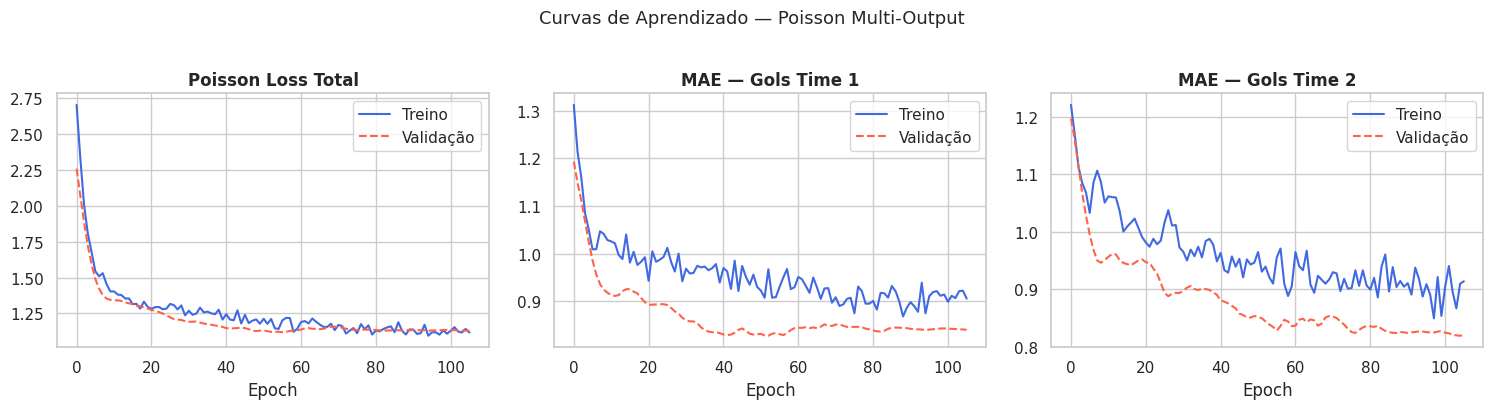

In [76]:
# Curvas de aprendizado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, m, tit in zip(axes,
    ['loss', 'gols_t1_mae', 'gols_t2_mae'],
    ['Poisson Loss Total', 'MAE — Gols Time 1', 'MAE — Gols Time 2']):
    ax.plot(historico.history[m],       label='Treino',    color='royalblue')
    ax.plot(historico.history[f'val_{m}'], label='Validação', color='tomato', ls='--')
    ax.set_title(tit, fontweight='bold'); ax.set_xlabel('Epoch'); ax.legend()

plt.suptitle('Curvas de Aprendizado — Poisson Multi-Output', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 📏 Célula 10 — Avaliação em 3 conjuntos

In [77]:
def avaliar(X_sc, y1_true, y2_true, label):
    preds = modelo.predict(X_sc, verbose=0)
    p1 = preds[0].flatten(); p2 = preds[1].flatten()
    mae1  = mean_absolute_error(y1_true, p1)
    mae2  = mean_absolute_error(y2_true, p2)
    rmse1 = mean_squared_error(y1_true, p1)**0.5
    rmse2 = mean_squared_error(y2_true, p2)**0.5
    acc   = np.mean(
        (np.round(p1).clip(0).astype(int) == y1_true.astype(int)) &
        (np.round(p2).clip(0).astype(int) == y2_true.astype(int))
    )
    print(f'  {label}')
    print(f'    MAE  T1:{mae1:.3f}  T2:{mae2:.3f}  Média:{(mae1+mae2)/2:.3f}')
    print(f'    RMSE T1:{rmse1:.3f}  T2:{rmse2:.3f}')
    print(f'    Placar exato: {acc*100:.1f}%')
    return p1, p2

print('📊 AVALIAÇÃO TEMPORAL')
print('═'*55)
avaliar(X_tr_sc,   y_tr1,    y_tr2,    'TREINO  (Copa 1950–2018)')
print()
avaliar(X_val_sc,  y_val1,   y_val2,   'VAL     (Copa 2022)')
print()
avaliar(X_test_sc, y_test1,  y_test2,  'TESTE   (Eliminatórias 2026)')
print('═'*55)
print('\n💡 A métrica mais importante é a do conjunto de VALIDAÇÃO (2022)')
print('   pois é o único genuinamente out-of-sample em relação ao treino.')

📊 AVALIAÇÃO TEMPORAL
═══════════════════════════════════════════════════════
  TREINO  (Copa 1950–2018)
    MAE  T1:0.886  T2:0.906  Média:0.896
    RMSE T1:1.229  T2:1.226
    Placar exato: 18.0%

  VAL     (Copa 2022)
    MAE  T1:0.831  T2:0.828  Média:0.830
    RMSE T1:1.061  T2:1.049
    Placar exato: 23.2%

  TESTE   (Eliminatórias 2026)
    MAE  T1:2.139  T2:1.973  Média:2.056
    RMSE T1:2.668  T2:2.489
    Placar exato: 4.7%
═══════════════════════════════════════════════════════

💡 A métrica mais importante é a do conjunto de VALIDAÇÃO (2022)
   pois é o único genuinamente out-of-sample em relação ao treino.


## 🔮 Célula 11 — Previsões Copa 2026

In [78]:
preds_copa = modelo.predict(X_copa_sc, verbose=0)
pf1 = preds_copa[0].flatten()
pf2 = preds_copa[1].flatten()
pi1 = np.round(pf1).astype(int).clip(0)
pi2 = np.round(pf2).astype(int).clip(0)

resultados = []
print('🏆 PREVISÕES — 1ª RODADA COPA DO MUNDO 2026')
print('═'*62)
for i,(jid,t1,t2) in enumerate(JOGOS_2026):
    g1,g2 = pi1[i],pi2[i]
    res = 'VITÓRIA' if g1>g2 else ('EMPATE' if g1==g2 else 'DERROTA')
    em  = '🔵' if g1>g2 else ('🟡' if g1==g2 else '🔴')
    sede = ' 🏟️' if (t1 in SEDE_2026 or t2 in SEDE_2026) else ''
    elo1 = elo_ratings.get(t1, ELO_INICIAL)
    elo2 = elo_ratings.get(t2, ELO_INICIAL)
    print(f'  {jid:7} │ {t1:3}({elo1:.0f}) {g1}×{g2} {t2:3}({elo2:.0f})  {em} {res}{sede}')
    resultados.append((jid,t1,t2,g1,g2,pf1[i],pf2[i]))
print('═'*62)
print('  🏟️ = jogo com país-sede (EUA/CAN/MEX)')

🏆 PREVISÕES — 1ª RODADA COPA DO MUNDO 2026
══════════════════════════════════════════════════════════════
  jogo1   │ MEX(1396) 0×1 RSA(1441)  🔴 DERROTA 🏟️
  jogo2   │ KOR(1466) 1×1 CZE(1500)  🟡 EMPATE
  jogo3   │ CAN(1497) 5×1 BIH(1475)  🔵 VITÓRIA 🏟️
  jogo4   │ USA(1490) 1×0 PAR(1429)  🔵 VITÓRIA 🏟️
  jogo5   │ HAI(1500) 1×1 SCO(1481)  🟡 EMPATE
  jogo6   │ AUS(1464) 2×1 TUR(1436)  🔵 VITÓRIA
  jogo7   │ BRA(1718) 2×0 MAR(1547)  🔵 VITÓRIA
  jogo8   │ QAT(1469) 1×3 SUI(1456)  🔴 DERROTA
  jogo9   │ CIV(1504) 1×1 ECU(1510)  🟡 EMPATE
  jogo10  │ GER(1713) 3×1 CUW(1500)  🔵 VITÓRIA
  jogo11  │ NED(1622) 1×1 JPN(1607)  🟡 EMPATE
  jogo12  │ SWE(1474) 1×1 TUN(1510)  🟡 EMPATE
  jogo13  │ KSA(1492) 0×3 URU(1586)  🔴 DERROTA
  jogo14  │ ESP(1570) 3×1 CPV(1500)  🔵 VITÓRIA
  jogo15  │ IRN(1480) 1×3 NZL(1530)  🔴 DERROTA
  jogo16  │ BEL(1563) 1×1 EGY(1530)  🟡 EMPATE
  jogo17  │ FRA(1778) 1×0 SEN(1499)  🔵 VITÓRIA
  jogo18  │ IRQ(1500) 0×2 NOR(1530)  🔴 DERROTA
  jogo19  │ ARG(1681) 2×1 ALG(1515)  🔵 VITÓRI

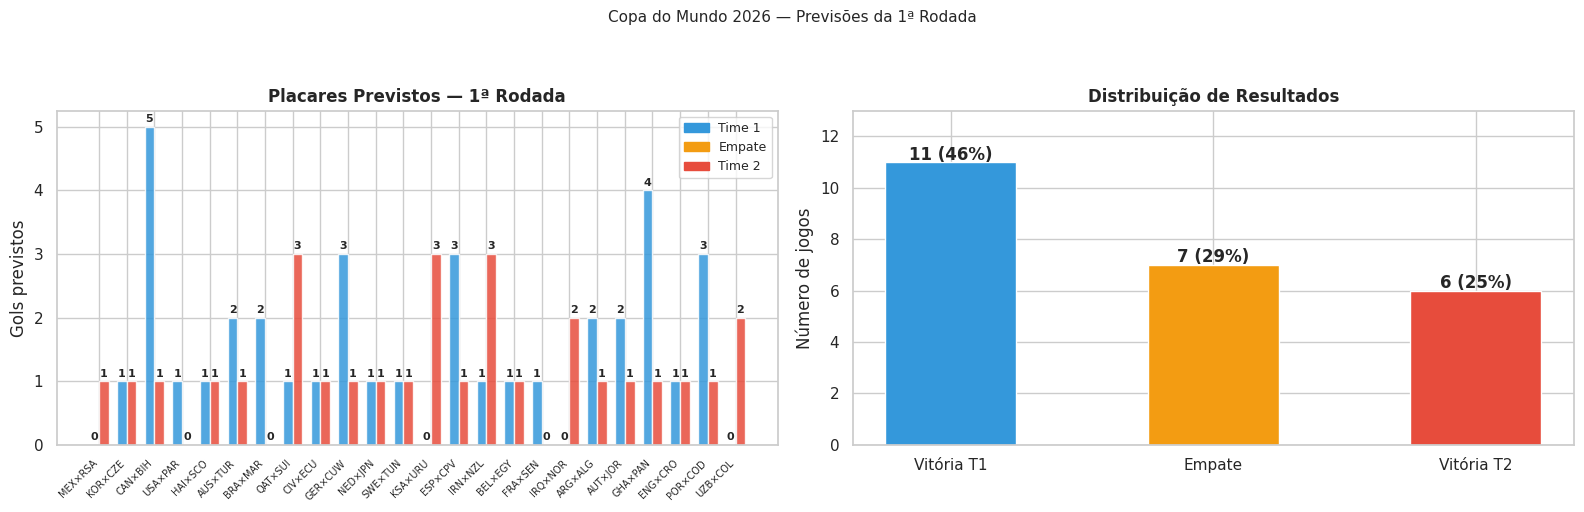

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras
ax = axes[0]
labels = [f'{t1}×{t2}' for _,t1,t2 in JOGOS_2026]
g1s=[r[3] for r in resultados]; g2s=[r[4] for r in resultados]
x=np.arange(len(labels)); w=0.35
b1=ax.bar(x-w/2,g1s,w,label='Time 1',color='#3498db',alpha=0.85,edgecolor='white')
b2=ax.bar(x+w/2,g2s,w,label='Time 2',color='#e74c3c',alpha=0.85,edgecolor='white')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.04,
            str(int(b.get_height())), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('Gols previstos'); ax.set_title('Placares Previstos — 1ª Rodada', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db',label='Time 1'),
                   Patch(color='#f39c12',label='Empate'),
                   Patch(color='#e74c3c',label='Time 2')], fontsize=9)

# Distribuição de resultados
ax2 = axes[1]
v1=sum(1 for r in resultados if r[3]>r[4])
em=sum(1 for r in resultados if r[3]==r[4])
v2=sum(1 for r in resultados if r[4]>r[3])
bars = ax2.bar(['Vitória T1','Empate','Vitória T2'],[v1,em,v2],
               color=['#3498db','#f39c12','#e74c3c'], edgecolor='white', width=0.5)
for bar,val in zip(bars,[v1,em,v2]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val} ({val/24*100:.0f}%)', ha='center', fontweight='bold')
ax2.set_title('Distribuição de Resultados', fontweight='bold')
ax2.set_ylabel('Número de jogos'); ax2.set_ylim(0, max(v1,em,v2)+2)

plt.suptitle('Copa do Mundo 2026 — Previsões da 1ª Rodada\n',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

## 💾 Célula 12 — Exportação do Bolão (TXT)

In [80]:
bolao = {'nome': 'ALEXANDRE GARCIA BEZERRA', 'turma': 'MESTRADO EM CIÊNCIA DE DADOS E IA', 'resultados': {}}
for jid,t1,t2,g1,g2,*_ in resultados:
    bolao['resultados'][jid] = {t1:{'gols':int(g1)}, t2:{'gols':int(g2)}}

ARQUIVO = 'bolao_copa.txt'
with open(ARQUIVO,'w',encoding='utf-8') as f:
    json.dump(bolao, f, ensure_ascii=False, indent=2)


from google.colab import files
files.download(ARQUIVO)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>